In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
file_path = "v1_lod_isobut.xlsx"
df = pd.read_excel(file_path)
df.head()

,Timestamp,Time (s),ENS160_R0 (Ohm),ENS160_R1 (Ohm),ENS160_R2 (Ohm),ENS160_R3 (Ohm),SGP41_VOC_R (Ohm),SGP41_NOx_R (Ohm),TGS2602 (Ohm)
0,2026-02-25 14:35:27.090,0.0,223667,1,66316,13482,27840,0,209.58
1,2026-02-25 14:35:28.090,1.0,226255,1,66182,13555,28145,0,199.4
2,2026-02-25 14:35:29.090,2.0,225415,1,68067,13482,28399,0,209.58
3,2026-02-25 14:35:30.100,3.0,222836,1,67403,13610,28601,0,209.58
4,2026-02-25 14:35:31.100,4.0,226026,1,68622,13573,28787,0,209.58


In [3]:
# CLEAN

# remove timestamp
df = df.drop(columns=['Timestamp']) 

# rename columns
df = df.rename(columns={"Time (s)": "Time_s",
                        "ENS160_R0 (Ohm)": "ENS160_R0",
                        "ENS160_R1 (Ohm)": "ENS160_R1",
                        "ENS160_R2 (Ohm)": "ENS160_R2",
                        "ENS160_R3 (Ohm)": "ENS160_R3",
                        "SGP41_VOC_R (Ohm)": "SGP41_VOC_R",
                        "SGP41_NOx_R (Ohm)": "SGP41_NOx_R",
                        "TGS2602 (Ohm)": "TGS2602_R"
                       })

# cutoff excess data
end_index = 62100 # 1035 min * 60 s
df = df.iloc[:end_index + 1]

# fix time_s column
df["Time_s"] = df["Time_s"] - df["Time_s"].iloc[0]

# add time (min) column
i = df.columns.get_loc("Time_s") + 1
df.insert(i, "Time_min", df["Time_s"] / 60)

# change "-" to null
df = df.replace('-', np.nan)

df.head(9)

,Time_s,Time_min,ENS160_R0,ENS160_R1,ENS160_R2,ENS160_R3,SGP41_VOC_R,SGP41_NOx_R,TGS2602_R
0,0.0,0.000000,223667,1,66316,13482,27840,0,209.58
1,1.0,0.016667,226255,1,66182,13555,28145,0,199.4
2,2.0,0.033333,225415,1,68067,13482,28399,0,209.58
3,3.0,0.050000,222836,1,67403,13610,28601,0,209.58
4,4.0,0.066667,226026,1,68622,13573,28787,0,209.58
5,5.0,0.083333,227176,1,69182,13739,28941,0,209.58
6,6.0,0.100000,225339,1,67517,13527,29064,0,209.58
7,7.0,0.116667,224349,1,68460,13409,29154,16177,199.4
8,8.0,0.133333,NaN,NaN,NaN,NaN,29353,16250,209.58


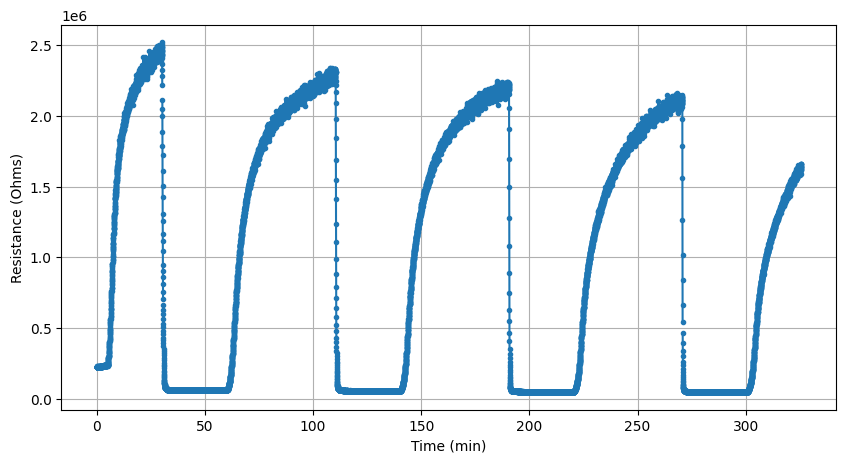

In [4]:
# plot resistances

# define segment
plot_df = df.iloc[:19500]

# plot
plt.figure(figsize=[10,5])
plt.plot(
    plot_df["Time_min"],
    plot_df["ENS160_R0"],
    marker="o",
    linestyle="-",
    markersize=3
)
#plt.title('ENS160 R0 Resistance Output to Ethylbenzene Dosing')
plt.xlabel('Time (min)')
plt.ylabel('Resistance (Ohms)')
plt.grid()
plt.show()

In [5]:
# calculation sensor response
res_cols = ["ENS160_R0", "ENS160_R1", "ENS160_R2", "ENS160_R3", "SGP41_VOC_R", "SGP41_NOx_R", "TGS2602_R"] #define all resistance columns

for col in res_cols:
    i = df.columns.get_loc(col) + 1
    r = df[col]
    r_max = df[col].max()
    s_col = col.replace("_R", "_S")

    r = df[col].replace(0, np.nan) # avoid divide by 0
    df.insert(i, s_col, np.where(r != 0, r_max / r - 1, np.nan))

In [6]:
df.head()

,Time_s,Time_min,ENS160_R0,ENS160_S0,ENS160_R1,ENS160_S1,ENS160_R2,ENS160_S2,ENS160_R3,ENS160_S3,SGP41_VOC_R,SGP41_VOC_S,SGP41_NOx_R,SGP41_NOx_S,TGS2602_R,TGS2602_S
0,0.0,0.000000,223667,10.267876,1,0.0,66316,17.720957,13482,16.519137,27840,0.263973,0,NaN,209.58,22.336339
1,1.0,0.016667,226255,10.138989,1,0.0,66182,17.758862,13555,16.424788,28145,0.250275,0,NaN,199.4,23.527733
2,2.0,0.033333,225415,10.180498,1,0.0,68067,17.239367,13482,16.519137,28399,0.239093,0,NaN,209.58,22.336339
3,3.0,0.050000,222836,10.309896,1,0.0,67403,17.419047,13610,16.354372,28601,0.230342,0,NaN,209.58,22.336339
4,4.0,0.066667,226026,10.150275,1,0.0,68622,17.091851,13573,16.40168,28787,0.222392,0,NaN,209.58,22.336339


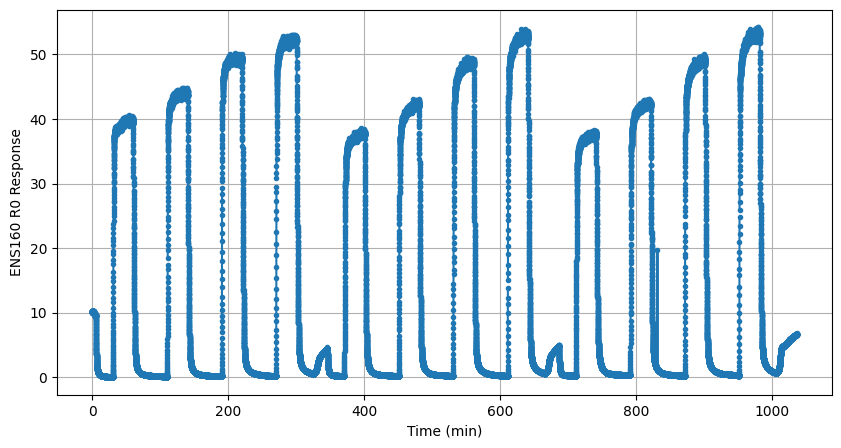

In [6]:
# cutoff excess data
end_index = 62100 # 1035 min * 60 s
df = df.iloc[:end_index + 1]

# plot sensitivities (response)
plt.figure(figsize=[10,5])
plt.plot(
    df["Time_min"],
    df["ENS160_S0"],
    marker="o",
    linestyle="-",
    markersize=3
)
#plt.title('ENS160 R0 Response to Ethylbenzene Dosing')
plt.xlabel('Time (min)')
plt.ylabel('ENS160 R0 Response')
plt.grid()
plt.show()

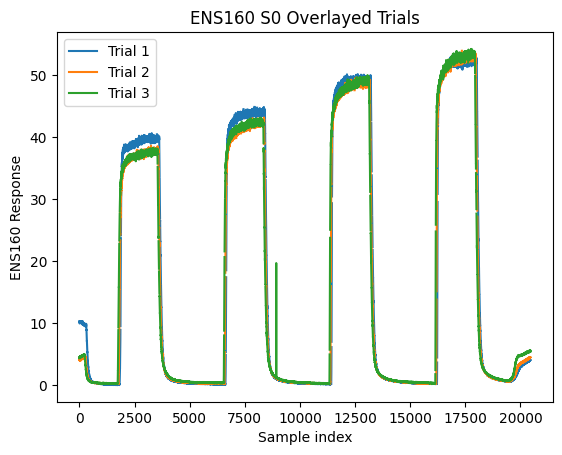

In [7]:
# check that trials are broken correctly
trial_len = 20450  # rows per trial

t1 = df.iloc[0 : trial_len]
t2 = df.iloc[trial_len : 2 * trial_len]
t3 = df.iloc[2 * trial_len : 3 * trial_len]

plt.figure()

plt.plot(
    t1.index - t1.index[0],
    t1["ENS160_S0"],
    label="Trial 1",
    markersize=2
)

plt.plot(
    t2.index - t2.index[0],
    t2["ENS160_S0"],
    label="Trial 2",
    markersize=2
)

plt.plot(
    t3.index - t3.index[0],
    t3["ENS160_S0"],
    label="Trial 3",
    markersize=2
)

plt.xlabel("Sample index")
plt.ylabel("ENS160 Response")
plt.title("ENS160 S0 Overlayed Trials")
plt.legend()
plt.show()


In [8]:
#RESHAPE BY ADDING TRIALS AS ANOTHER SET OF COLUMNS
# split trials by index
df_t1 = df.iloc[0 : trial_len].copy()
df_t2 = df.iloc[trial_len : 2 * trial_len].copy()
df_t3 = df.iloc[2 * trial_len : 3 * trial_len].copy()

# reset indices so rows align
df_t1.reset_index(drop=True, inplace=True)
df_t2.reset_index(drop=True, inplace=True)
df_t3.reset_index(drop=True, inplace=True)

# rename columns for t2 and t3
df_t1.columns = [f"{c}_t1" for c in df_t1.columns]
df_t2.columns = [f"{c}_t2" for c in df_t2.columns]
df_t3.columns = [f"{c}_t3" for c in df_t3.columns]

# concatenate column-wise
trial_df = pd.concat([df_t1, df_t2, df_t3], axis=1)

keep_mask = (
    ~trial_df.columns.str.contains("_R") &
    ~trial_df.columns.str.contains("Timestamp") &
    ~trial_df.columns.str.contains("Time_min") &
    (
        ~trial_df.columns.str.contains("Time_s") |
        trial_df.columns.str.endswith("_t1")
    )
)

trial_df = trial_df.loc[:, keep_mask].copy()

In [10]:
trial_df

,Time_s_t1,ENS160_S0_t1,ENS160_S1_t1,ENS160_S2_t1,ENS160_S3_t1,SGP41_VOC_S_t1,SGP41_NOx_S_t1,TGS2602_S_t1,ENS160_S0_t2,ENS160_S1_t2,...,SGP41_VOC_S_t2,SGP41_NOx_S_t2,TGS2602_S_t2,ENS160_S0_t3,ENS160_S1_t3,ENS160_S2_t3,ENS160_S3_t3,SGP41_VOC_S_t3,SGP41_NOx_S_t3,TGS2602_S_t3
0,0.00,10.267876,0.0,17.720957,16.519137,0.263973,NaN,22.336339,4.041966,0.0,...,0.159822,0.097825,3.668961,4.404219,0.0,5.49452,6.298918,0.167983,0.099310,3.89083
1,1.00,10.138989,0.0,17.758862,16.424788,0.250275,NaN,23.527733,4.024927,0.0,...,0.159822,0.098196,3.668961,4.309941,0.0,5.686337,6.26949,0.167867,0.099980,3.89083
2,2.00,10.180498,0.0,17.239367,16.519137,0.239093,NaN,22.336339,3.964077,0.0,...,0.159478,0.097973,3.668961,4.358681,0.0,5.589732,6.291483,0.167828,0.099756,3.89083
3,3.00,10.309896,0.0,17.419047,16.354372,0.230342,NaN,22.336339,4.030042,0.0,...,0.159593,0.097825,3.668961,4.451987,0.0,5.543056,6.350938,0.167906,0.099682,3.89083
4,4.00,10.150275,0.0,17.091851,16.40168,0.222392,NaN,22.336339,3.977528,0.0,...,0.159784,0.098344,3.668961,4.466758,0.0,5.636725,6.3014,0.167828,0.099608,3.949331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20445,20477.72,4.02663,0.0,5.263522,5.860691,0.159440,0.097899,3.722702,4.404219,0.0,...,0.167247,0.099384,3.89083,5.476949,0.0,6.967622,7.969809,0.177796,0.096713,5.094264
20446,20478.72,4.047096,0.0,5.418039,5.754547,0.159402,0.097825,3.668961,4.437237,0.0,...,0.167557,0.099384,3.89083,5.514333,0.0,6.895115,7.858123,0.178348,0.096639,5.094264
20447,20479.72,3.985967,0.0,5.353206,5.639111,0.159593,0.098418,3.722702,4.389599,0.0,...,0.167634,0.099384,3.89083,5.598658,0.0,6.820663,8.055091,0.177953,0.096713,5.094264
20448,20480.72,4.033447,0.0,5.233927,6.034578,0.159746,0.097825,3.668961,4.385959,0.0,...,0.167402,0.099682,3.949331,5.531993,0.0,7.018983,8.284681,0.178151,0.096935,5.094264


In [9]:
# calculate means and sds
s_cols = ["ENS160_S0", "ENS160_S1", "ENS160_S2", "ENS160_S3", "SGP41_VOC_S", "SGP41_NOx_S", "TGS2602_S"] #define all resistance columns

calc_df = pd.DataFrame()
calc_df["Time_s"] = trial_df["Time_s_t1"]

for s in s_cols:
    trial_cols = [f"{s}_t1", f"{s}_t2", f"{s}_t3"]

    calc_df[f"{s}_mean"] = trial_df[trial_cols].mean(axis=1)
    calc_df[f"{s}_std"]  = trial_df[trial_cols].std(axis=1)


In [12]:
calc_df

,Time_s,ENS160_S0_mean,ENS160_S0_std,ENS160_S1_mean,ENS160_S1_std,ENS160_S2_mean,ENS160_S2_std,ENS160_S3_mean,ENS160_S3_std,SGP41_VOC_S_mean,SGP41_VOC_S_std,SGP41_NOx_S_mean,SGP41_NOx_S_std,TGS2602_S_mean,TGS2602_S_std
0,0.00,6.23802,3.494654,0.0,0.0,9.425572,7.18728,9.589188,6.004054,0.197259,0.057919,0.098567,0.001050,9.965377,10.714142
1,1.00,6.157952,3.450623,0.0,0.0,9.541505,7.120953,9.486812,6.013732,0.192655,0.050063,0.099088,0.001262,10.362508,11.401959
2,2.00,6.167752,3.480736,0.0,0.0,9.382666,6.805451,9.535521,6.053062,0.188800,0.043755,0.098865,0.001261,9.965377,10.714142
3,3.00,6.263975,3.510216,0.0,0.0,9.417757,6.930465,9.539875,5.905564,0.185947,0.038671,0.098753,0.001313,9.965377,10.714142
4,4.00,6.198187,3.431339,0.0,0.0,9.372813,6.686023,9.54848,5.937759,0.183335,0.034063,0.098976,0.000893,9.984877,10.697599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20445,20477.72,4.635933,0.752412,0.0,0.0,5.961208,0.893014,6.690932,1.123855,0.168161,0.009212,0.097999,0.001338,4.235932,0.748076
20446,20478.72,4.666222,0.759948,0.0,0.0,5.982548,0.797682,6.59719,1.112422,0.168435,0.009504,0.097949,0.001377,4.218018,0.766917
20447,20479.72,4.658075,0.839198,0.0,0.0,5.907125,0.79709,6.624367,1.268097,0.168394,0.009204,0.098172,0.001352,4.235932,0.748076
20448,20480.72,4.650467,0.783507,0.0,0.0,5.937162,0.950843,6.903407,1.209417,0.168433,0.009246,0.098147,0.001401,4.237519,0.75509


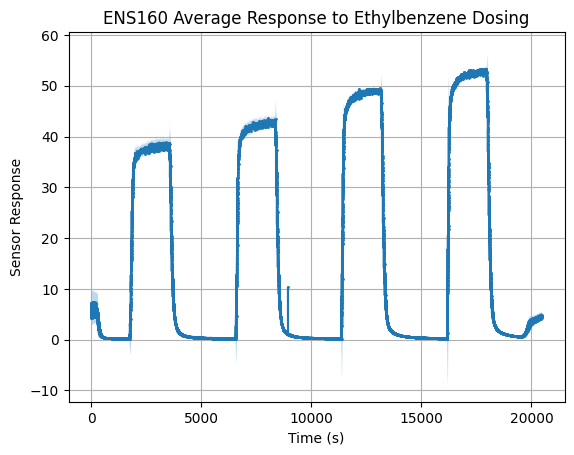

In [10]:
time = calc_df["Time_s"].astype(float).to_numpy()
avg = calc_df["ENS160_S0_mean"].astype(float).to_numpy()
std = calc_df["ENS160_S0_std"].astype(float).to_numpy()

mask = np.isfinite(time) & np.isfinite(avg) & np.isfinite(std)
time, avg, std = time[mask], avg[mask], std[mask]

line, = plt.plot(
    time,
    avg,
    marker="o",
    markersize=1,
    linestyle="-"
)

plt.fill_between(
    time,
    avg - std,
    avg + std,
    alpha=0.3
)

plt.xlabel("Time (s)")
plt.ylabel("Sensor Response")
plt.title("ENS160 Average Response to Ethylbenzene Dosing")
plt.grid()
plt.show()

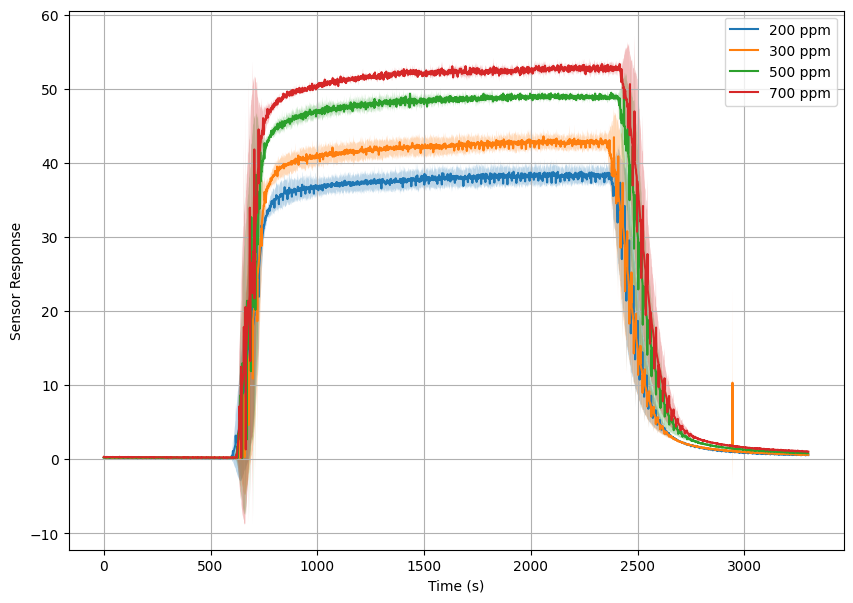

In [11]:
mask = np.isfinite(time) & np.isfinite(avg) & np.isfinite(std)
time, avg, std = time[mask], avg[mask], std[mask]

onsets = [1400, 6150, 10880, 15610]
pre = 300
post = 3000
labels = ["200 ppm", "300 ppm", "500 ppm", "700 ppm"]
dt = 1 #s

plt.figure(figsize=[10,7])

for i, onset in enumerate(onsets):
    start = onset - pre
    end   = onset + post

    a = avg[start:end]
    s = std[start:end]
    t = np.arange(0, pre+post) * dt

    plt.plot(t, a, label=labels[i])
    plt.fill_between(t, a - s, a + s, alpha=0.3)

plt.xlabel("Time (s)")
plt.ylabel("Sensor Response")
#plt.title("ENS160 R0 Response to Ethylbenzene Dosing")
#plt.xlim([1500,4000])
#plt.ylim([0,300])
plt.legend()
plt.grid()
plt.show()


Baseline σ: 0.03414
3σ noise: 0.1024
Slope (m): 0.02843 response/ppm
Estimated LOD: 3.60 ppm
[366.06885181 409.15565828 469.73930679 506.27446124]
SNR at 200 ppm: 51.27
SNR at 300 ppm: 52.24
SNR at 500 ppm: 53.44
SNR at 700 ppm: 54.09


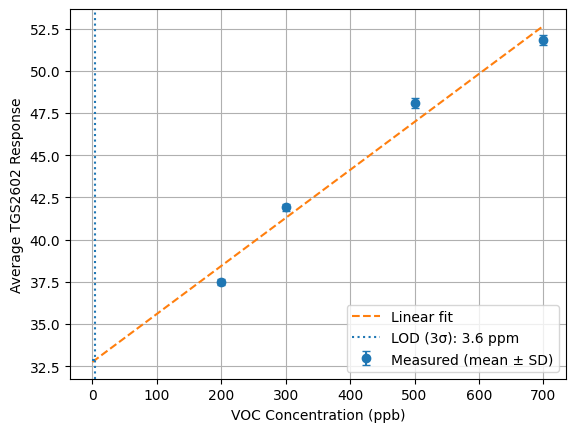

In [12]:
concs = [200, 300, 500, 700] # ppb

# define baseline window
baseline_end = onsets[0] - 1
baseline_start = max(0, baseline_end - 600)  # 10 min
baseline_region = avg[baseline_start:baseline_end]

# calculate baseline noise (sigma)
sigma = np.nanstd(baseline_region, ddof=1)
noise_3sigma = 3 * sigma

# compute response from end of dosing window
pre = 900 # 15 min into dosing
post = 1140 # 19 min into dosing
avg_responses = []
err_responses = []
for onset in onsets:
    start = onset + pre
    end   = onset + post

    #find mean and SD of segment
    seg = avg[start:end]
    avg_responses.append(np.nanmean(avg[start:end]))
    err_responses.append(np.nanstd(seg, ddof=1))

# fit calibration curve
m, b = np.polyfit(concs, avg_responses, 1)  # response = m * C + b

LOD_ppm = noise_3sigma / m  # LOD = 3σ / slope
print(f"Baseline σ: {sigma:.4g}")
print(f"3σ noise: {noise_3sigma:.4g}")
print(f"Slope (m): {m:.4g} response/ppm")
print(f"Estimated LOD: {LOD_ppm:.2f} ppm")

snr = avg_responses / noise_3sigma
print(snr)
snr = 20 * np.log10(snr)
for c, s in zip(concs, snr):
    print(f"SNR at {c:.0f} ppm: {s:.2f}")

plt.figure()
# points + error bars
plt.errorbar(
    concs, avg_responses,
    yerr=err_responses,
    fmt="o",
    capsize=3,
    label="Measured (mean ± SD)"
)

# fit line, extend to LOD
x_end = max(concs[-1], LOD_ppm)
xfit = np.linspace(0, x_end, 200)
yfit = m * xfit + b
plt.plot(xfit, yfit, linestyle="--", label="Linear fit")

# LOD marker
plt.axvline(LOD_ppm, linestyle=":", label=f"LOD (3σ): {LOD_ppm:.1f} ppm")

# horizontal line at the response level where the fit hits LOD
y_at_LOD = m * LOD_ppm + b
plt.hlines(
    y=y_at_LOD,
    xmin=0,
    xmax=LOD_ppm,
)

plt.xlabel("VOC Concentration (ppb)")
plt.ylabel("Average TGS2602 Response")
#plt.title("ENS160 R0 Steady-State Response to Ethylbenzene")
plt.grid()
plt.legend()
plt.show()

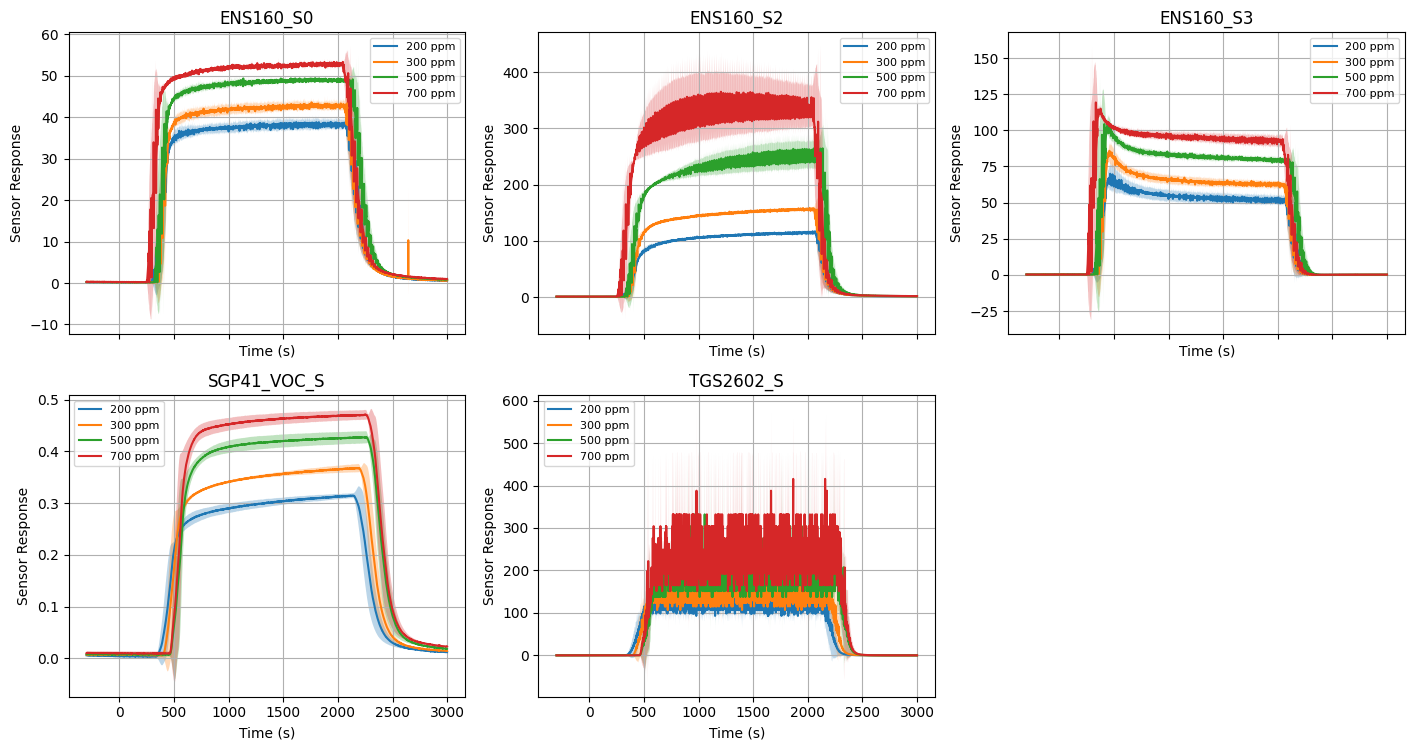

In [15]:
# PLOTS FOR ALL SENSORS
# drop
#calc_df = calc_df.drop(columns=['ENS160_S1_mean','ENS160_S1_std', 'SGP41_NOx_S_mean', 'SGP41_NOx_S_std'])

onsets = [1400, 6150, 10880, 15680]
pre = 300
post = 3000
labels = ["200 ppm", "300 ppm", "500 ppm", "700 ppm"]
dt = 1 #s

# extract column names
cols = list(calc_df.columns)
time_col = cols[0]
sensor_cols = cols[1:] # mean & std pairs
n_sensors = len(sensor_cols) // 2

ncols = 3
nrows = int(np.ceil(n_sensors / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4*nrows),
    sharex=True
)

axes = axes.flatten()

# loop through sensors
for i in range(n_sensors):
    ax = axes[i]

    mean_col = sensor_cols[2*i]
    std_col  = sensor_cols[2*i + 1]

    time = calc_df[time_col].astype(float).to_numpy()
    avg  = calc_df[mean_col].astype(float).to_numpy()
    std  = calc_df[std_col].astype(float).to_numpy()

    mask = np.isfinite(time) & np.isfinite(avg) & np.isfinite(std)
    avg, std = avg[mask], std[mask]

    for j, onset in enumerate(onsets):
        start = onset - pre
        end   = onset + post

        if start < 0 or end > len(avg):
            continue

        a = avg[start:end]
        s = std[start:end]
        t = np.arange(-pre, post) * dt

        n = min(len(t), len(a), len(s))
        ax.plot(t[:n], a[:n], label=labels[j])
        ax.fill_between(
            t[:n],
            (a - s)[:n],
            (a + s)[:n],
            alpha=0.3
        )

    ax.set_title(mean_col.replace("_mean", ""))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Sensor Response")
    ax.grid(True)
    ax.legend(fontsize=8)

#hide unused subplots
for ax in axes[n_sensors:]:
    ax.axis("off")

#fig.suptitle("Sensor Responses to Ethylbenzene Dosing", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

In [16]:
import json
voc_name = "isobutyraldehyde"

calc_df.to_csv(f"{voc_name}_clean.csv", index=False)

meta = {
    "voc_name": "isobutyraldehyde",
    "unit": "ppm",
    "onsets": [1400, 6150, 10880, 15680],
    "labels": ["200 ppm", "300 ppm", "500 ppm", "700 ppm"],
    "pre": 300,
    "post": 3000,
    "dt": 1
}

with open(f"{voc_name}_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

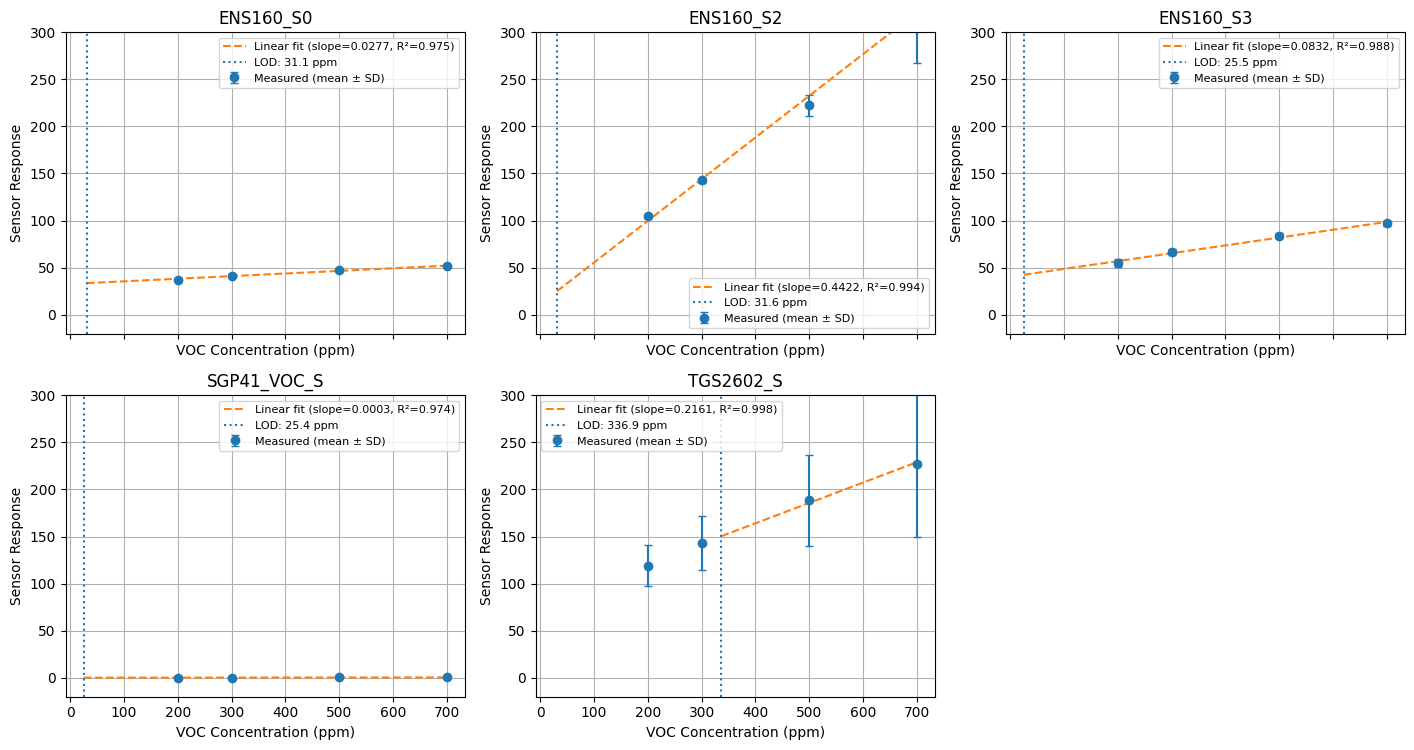

        Sensor   Slope      R2   LOD_ppm      SNR
0    ENS160_S0  0.0277  0.9751   31.1494  43.7955
1    ENS160_S2  0.4422  0.9942   31.5529  32.6319
2    ENS160_S3  0.0832  0.9885   25.5079  40.5888
3  SGP41_VOC_S  0.0003  0.9741   25.4437  42.7895
4    TGS2602_S  0.2161  0.9978  336.9436  16.8754


In [20]:
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4*nrows),
    sharex=True
)

axes = axes.flatten()
results = []

# loop through sensors
for i in range(n_sensors):
    ax = axes[i]

    mean_col = sensor_cols[2*i]
    std_col  = sensor_cols[2*i + 1]

    # compute response from end of dosing window
    pre = 900 # 15 min into dosing
    post = 1140 # 19 min into dosing
    avg_responses = []
    err_responses = []
    noises = []
    
    mean_data = calc_df[mean_col].values
    std_data  = calc_df[std_col].values

    # compute points + error bars + signal noise
    for onset in onsets:
        start = onset + pre
        end   = onset + post
        #find mean and SD of segment
        segment_mean = mean_data[start:end]
        segment_std  = std_data[start:end]
        avg_responses.append(np.nanmean(segment_mean))
        err_responses.append(np.sqrt(np.nanmean(segment_std**2)))
        # signal noise
        noises.append(np.nanstd(mean_data[start:end], ddof=1))
    
    # fit calibration curve
    m, b = np.polyfit(concs, avg_responses, 1)  # response = m * C + b

    # predictions and R^2
    avg_responses = np.array(avg_responses, dtype=float)
    #noises = np.array(noises, dtype=float)
    yhat = m * np.array(concs) + b
    ss_res = np.nansum((avg_responses - yhat)**2)
    ss_tot = np.nansum((avg_responses - np.nanmean(avg_responses))**2)
    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    # single noise estimate for this sensor
    sigma_mean = np.nanmean(noises)

    # LOD using simplified IUPAC formula
    LOD_ppm = (3 * sigma_mean) / abs(m)

    # SNR
    noise_mean = np.nanmean(noises)
    mean_response = np.nanmean(avg_responses)
    snr = mean_response / noise_mean
    snr_db = 20 * np.log10(snr)

    # points + errorbars
    ax.errorbar(
        concs, avg_responses,
        yerr=err_responses,
        fmt="o",
        capsize=3,
        label="Measured (mean ± SD)"
    )
    # fit line, extend to LOD
    x_end   = max(concs)
    xfit = np.linspace(LOD_ppm, x_end, 200)
    yfit = m * xfit + b
    ax.plot(xfit, yfit, linestyle="--", label=f"Linear fit (slope={m:.4f}, R²={R2:.3f})")

    # LOD marker
    ax.axvline(LOD_ppm, linestyle=":", label=f"LOD: {LOD_ppm:.1f} ppm")

    ax.set_title(mean_col.replace("_mean", ""))
    ax.set_xlabel("VOC Concentration (ppm)")
    ax.set_ylabel("Sensor Response")
    ax.set_ylim(-20,300)
    ax.grid(True)
    ax.legend(fontsize=8)

    # add to results
    sensor_name = mean_col.replace("_mean", "")
    results.append({
        "Sensor": sensor_name,
        "Slope": m,
        "R2": R2,
        "LOD_ppm": LOD_ppm,
        "SNR": snr_db
    })
    
#hide unused subplots
for ax in axes[n_sensors:]:
    ax.axis("off")
    
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

results_df = pd.DataFrame(results)
print(results_df.round(4))

In [18]:
# calculate max average signal for each conc

# --- τ Rising ---
'''baseline = avg_curve.iloc[:10].mean() # 
t0_idx = 36  # corresponds to 180s
t0_val = time[t0_idx]

y_tau_rise = baseline + 0.632 * (max_val - baseline)'''

df_results = pd.DataFrame(columns=['tau_rise', 'tau_fall', 'SNR', 'LOD', 'beta', 'R2'])
df_results

,tau_rise,tau_fall,SNR,LOD,beta,R2
